# 한국 주식 변동성(Volatility) - 수익률(Return) 관계 분석

25일 / 60일 / 120일 기준으로:
1. 실현 변동성(연율화)을 계산하고
2. 같은 기간의 수익률(동시기 + 이후 N일 선행 수익률)을 계산한 뒤
3. 두 변수 간의 관계를 회귀분석/상관분석으로 측정하고
4. 두 가지 관계(① 동시기 관계, ② 변동성 → 이후 수익률 예측 관계)를 시각화합니다.

- 데이터 소스: `FinanceDataReader` (KRX)
- ① **동시기(contemporaneous) 관계**: t시점의 N일 변동성 vs. t시점까지의 N일 수익률
  → 레버리지 효과(하락장에서 변동성 상승) 여부 확인
- ② **예측(predictive/leading) 관계**: t시점의 N일 변동성 vs. t시점 이후 N일간의 수익률
  → 고변동성 국면 이후 수익률(위험프리미엄/평균회귀) 여부 확인


In [48]:
# Cell 1: 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

import FinanceDataReader as fdr

# 한글 폰트 설정 (환경에 맞는 폰트가 없으면 자동으로 기본 폰트 사용)
for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if f in [x.name for x in fm.fontManager.ttflist]:
        plt.rcParams["font.family"] = f
        break
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [49]:
# Cell 2: 사용자 입력 변수 (여기만 수정하면 됩니다)

TICKER = "000660"          # 종목코드 (예: 삼성전자 = 005930). FDR StockListing("KRX")로 종목 검색 가능
TICKER_NAME = "SK하이닉스"    # 차트 제목용 종목명 (직접 입력)

START_DATE = "2015-01-01"  # 조회 시작일
END_DATE = None            # 조회 종료일 (None이면 오늘까지)

WINDOWS = [25, 60, 120]    # 분석할 롤링 윈도우 (거래일 기준)
TRADING_DAYS = 252         # 연율화 계수 (변동성 * sqrt(TRADING_DAYS))

# 변동성 계산 방식: "log" (로그수익률 표준편차, 표준적 방식) 또는 "pct" (단순수익률)
VOL_RETURN_TYPE = "log"

# --- 구간 분할(regime) 분석 설정 ---
REGIME_SPLIT_DATE = "2024-01-01"  # 고정 날짜 분할 기준일 (이 날짜 이전 vs. 이후로 비교)
REGIME_DD_THRESHOLD = 0.20        # 추세 기반 강세장/약세장 분류 기준: 고점대비 -20% 하락 시 약세장, 저점대비 +20% 반등 시 강세장 (표준적인 20% 룰)

# --- 국면 고정효과(regime fixed-effects) 분석 설정 ---
MIN_EPISODE_OBS = 60  # 국면(episode) 내 유효 관측치 최소 개수. 너무 짧은 국면은 회귀분석 대상에서 제외 (권장: WINDOWS 최대값 이상)

# --- 유사 국면(analog) 탐색 설정 ---
ANALOG_N_MATCHES = 15               # 찾을 유사 과거 시점 개수 (최대)
ANALOG_MIN_GAP_DAYS = 90             # 선택된 유사 시점들 간 최소 거래일 간격 (같은 날짜 근처 중복 방지)
ANALOG_EXCLUDE_RECENT_DAYS = max(WINDOWS)  # 현재 시점과 너무 가까운 과거(윈도우가 겹치는 구간)는 후보에서 제외
ANALOG_FORWARD_HORIZONS = [25, 60, 120, 250]  # 유사 시점 발견 이후 몇 거래일 후 수익률을 확인할지

# 유사 국면 탐색 시, 현재와 수익률 "방향(부호)"까지 일치하는 시점만 후보로 남길지 여부
# True  -> "변동성도 크고 수익률도 같은 방향(예: 둘 다 상승 = 멜트업)"인 시점만 비교
# False -> 방향 무관, 변동성/수익률 "크기"만으로 비교 (기존 방식, 폭락/폭등이 섞여서 나올 수 있음)
ANALOG_REQUIRE_SAME_DIRECTION = True


In [50]:
# Cell 3: 주가 데이터 로딩
from typing import Optional

def load_price(ticker: str, start: str, end: Optional[str]) -> pd.DataFrame:
    """FinanceDataReader로 종가 데이터를 로딩합니다."""
    df = fdr.DataReader(ticker, start, end)
    if df is None or df.empty:
        raise ValueError(f"'{ticker}' 데이터를 가져오지 못했습니다. 종목코드/기간을 확인하세요.")
    df = df[["Close"]].copy()
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="last")]
    return df


price_df = load_price(TICKER, START_DATE, END_DATE)
print(f"{TICKER_NAME}({TICKER}) 데이터 로딩 완료: {price_df.index.min().date()} ~ {price_df.index.max().date()}, {len(price_df):,}거래일")
price_df.tail()


SK하이닉스(000660) 데이터 로딩 완료: 2015-01-02 ~ 2026-07-16, 2,832거래일


,Close
Date,
2026-07-10,2180000
2026-07-13,1845000
2026-07-14,1913000
2026-07-15,2082000
2026-07-16,1842000


In [51]:
# Cell 4: 롤링 변동성 / 롤링 수익률(동시기 + 선행) 계산

def compute_vol_return(df: pd.DataFrame, windows: list[int],
                        trading_days: int = 252, vol_type: str = "log") -> pd.DataFrame:
    out = df.copy()

    if vol_type == "log":
        out["ret_1d"] = np.log(out["Close"] / out["Close"].shift(1))
    else:
        out["ret_1d"] = out["Close"].pct_change()

    for w in windows:
        # 실현 변동성 (연율화): 최근 w일 일간수익률의 표준편차 * sqrt(trading_days)
        out[f"vol_{w}"] = out["ret_1d"].rolling(w).std() * np.sqrt(trading_days)

        # 동시기 수익률: t시점 기준 과거 w일간 누적수익률 (변동성과 같은 구간)
        out[f"ret_{w}"] = out["Close"].pct_change(w)

        # 선행(예측) 수익률: t시점 이후 w일간의 누적수익률 (변동성이 미래 수익률을 설명하는지)
        out[f"fwd_ret_{w}"] = out["Close"].shift(-w) / out["Close"] - 1

    return out


analysis_df = compute_vol_return(price_df, WINDOWS, TRADING_DAYS, VOL_RETURN_TYPE)
analysis_df[["Close"] + [f"vol_{w}" for w in WINDOWS] + [f"ret_{w}" for w in WINDOWS]].tail()


,Close,vol_25,vol_60,vol_120,ret_25,ret_60,ret_120
Date,,,,,,,
2026-07-10,2180000,1.2152,0.9934,0.9425,0.0531,1.0962,1.9539
2026-07-13,1845000,1.3048,1.0541,0.9763,-0.0345,0.6727,1.4865
2026-07-14,1913000,1.2161,1.0548,0.9772,-0.1363,0.6840,1.5541
2026-07-15,2082000,1.2242,1.0661,0.9835,0.0166,0.8026,1.7540
2026-07-16,1842000,1.2815,1.0981,1.0016,-0.1233,0.6330,1.4110


In [52]:
# Cell 5: 관계 측정 - 상관분석 & 단순선형회귀 (동시기 vs. 선행 두 가지 관점)

def relationship_stats(df: pd.DataFrame, windows: list[int], y_prefix: str) -> pd.DataFrame:
    """각 윈도우별로 vol_w vs. {y_prefix}_w 의 상관계수, 회귀계수, p-value 등을 요약"""
    rows = []
    for w in windows:
        sub = df[[f"vol_{w}", f"{y_prefix}_{w}"]].dropna()
        x, y = sub[f"vol_{w}"].values, sub[f"{y_prefix}_{w}"].values
        slope, intercept, r, p, se = stats.linregress(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)
        rows.append({
            "window": w,
            "n_obs": len(sub),
            "pearson_r": r,
            "r_squared": r ** 2,
            "p_value": p,
            "spearman_r": spearman_r,
            "slope": slope,
            "intercept": intercept,
            "std_err": se,
        })
    return pd.DataFrame(rows).set_index("window")


contemp_stats = relationship_stats(analysis_df, WINDOWS, "ret")       # ① 동시기 관계
predictive_stats = relationship_stats(analysis_df, WINDOWS, "fwd_ret")  # ② 선행(예측) 관계

print("=" * 70)
print("① 동시기 관계: N일 변동성 vs. 같은 N일간 수익률 (레버리지 효과 검증)")
print("=" * 70)
display(contemp_stats)

print()
print("=" * 70)
print("② 선행 관계: N일 변동성 vs. 이후 N일간 수익률 (변동성의 예측력 검증)")
print("=" * 70)
display(predictive_stats)


① 동시기 관계: N일 변동성 vs. 같은 N일간 수익률 (레버리지 효과 검증)


,n_obs,pearson_r,r_squared,p_value,spearman_r,slope,intercept,std_err
window,,,,,,,,
25,2807,0.2589,0.0670,0.0000,0.1106,0.2716,-0.0623,0.0191
60,2772,0.5324,0.2835,0.0000,0.1727,1.2233,-0.3746,0.0370
120,2712,0.6216,0.3864,0.0000,0.1314,3.4121,-1.1088,0.0826



② 선행 관계: N일 변동성 vs. 이후 N일간 수익률 (변동성의 예측력 검증)


,n_obs,pearson_r,r_squared,p_value,spearman_r,slope,intercept,std_err
window,,,,,,,,
25,2782,0.3241,0.1050,0.0000,0.0943,0.3818,-0.1029,0.0211
60,2712,0.4190,0.1755,0.0000,0.0992,1.2250,-0.3580,0.0510
120,2592,0.4837,0.2340,0.0000,0.1308,3.9467,-1.2344,0.1403


In [53]:
# Cell 6: 해석 요약 출력

def interpret(stats_df: pd.DataFrame, label: str):
    print(f"[{label}]")
    for w, row in stats_df.iterrows():
        sig = "유의함(p<0.05)" if row["p_value"] < 0.05 else "유의하지 않음"
        direction = "음(-)의 관계" if row["pearson_r"] < 0 else "양(+)의 관계"
        strength = (
            "약함" if abs(row["pearson_r"]) < 0.1 else
            "중간" if abs(row["pearson_r"]) < 0.3 else
            "강함"
        )
        print(f"  - {w}일: r={row['pearson_r']:.3f} ({direction}, 강도 {strength}), "
              f"R²={row['r_squared']:.3f}, p={row['p_value']:.4f} [{sig}]")
    print()

interpret(contemp_stats, "① 동시기: 변동성 vs. 동기간 수익률")
interpret(predictive_stats, "② 선행: 변동성 vs. 이후 수익률")


[① 동시기: 변동성 vs. 동기간 수익률]
  - 25일: r=0.259 (양(+)의 관계, 강도 중간), R²=0.067, p=0.0000 [유의함(p<0.05)]
  - 60일: r=0.532 (양(+)의 관계, 강도 강함), R²=0.283, p=0.0000 [유의함(p<0.05)]
  - 120일: r=0.622 (양(+)의 관계, 강도 강함), R²=0.386, p=0.0000 [유의함(p<0.05)]

[② 선행: 변동성 vs. 이후 수익률]
  - 25일: r=0.324 (양(+)의 관계, 강도 강함), R²=0.105, p=0.0000 [유의함(p<0.05)]
  - 60일: r=0.419 (양(+)의 관계, 강도 강함), R²=0.176, p=0.0000 [유의함(p<0.05)]
  - 120일: r=0.484 (양(+)의 관계, 강도 강함), R²=0.234, p=0.0000 [유의함(p<0.05)]



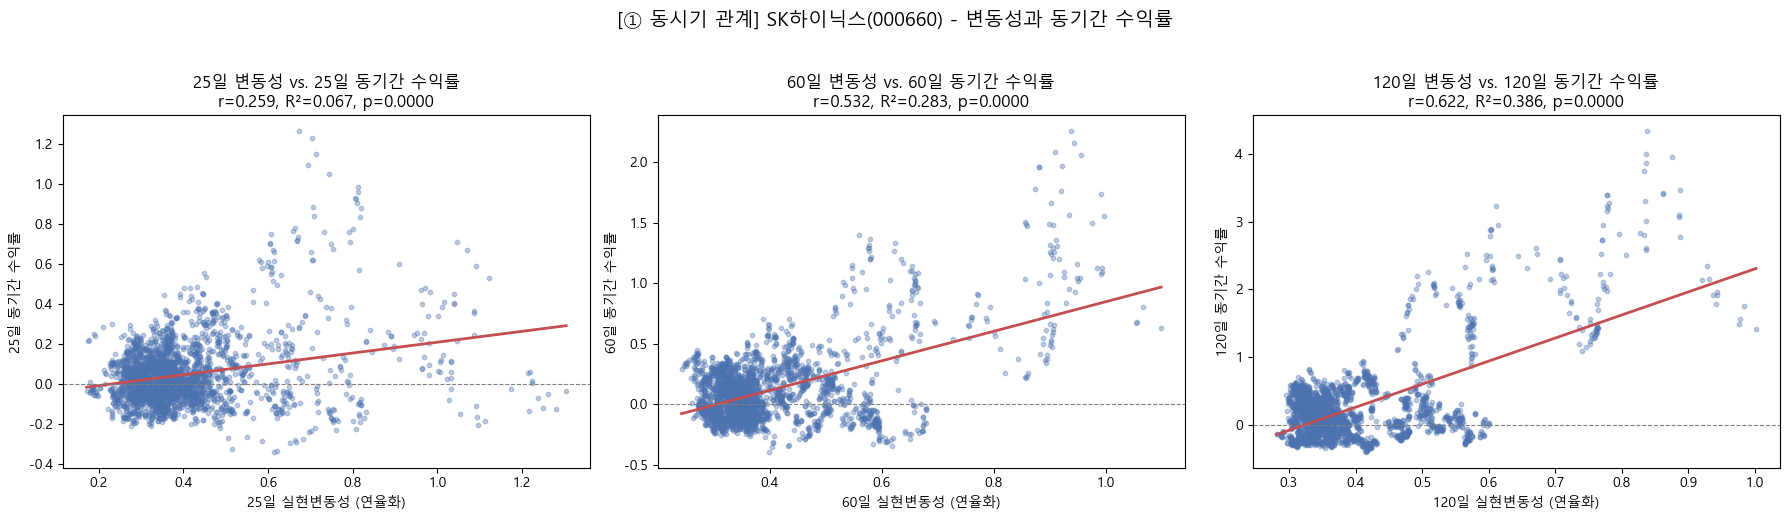

In [54]:
# Cell 7: [시각화 1] 동시기 관계 - 변동성 vs. 동기간 수익률 (산점도 + 회귀선)

fig, axes = plt.subplots(1, len(WINDOWS), figsize=(6 * len(WINDOWS), 5), sharey=False)
if len(WINDOWS) == 1:
    axes = [axes]

for ax, w in zip(axes, WINDOWS):
    sub = analysis_df[[f"vol_{w}", f"ret_{w}"]].dropna()
    x, y = sub[f"vol_{w}"], sub[f"ret_{w}"]
    row = contemp_stats.loc[w]

    ax.scatter(x, y, s=10, alpha=0.35, color="#4C72B0")
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, row["intercept"] + row["slope"] * xs, color="#C44E52", linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    ax.set_title(f"{w}일 변동성 vs. {w}일 동기간 수익률\nr={row['pearson_r']:.3f}, R²={row['r_squared']:.3f}, p={row['p_value']:.4f}")
    ax.set_xlabel(f"{w}일 실현변동성 (연율화)")
    ax.set_ylabel(f"{w}일 동기간 수익률")

fig.suptitle(f"[① 동시기 관계] {TICKER_NAME}({TICKER}) - 변동성과 동기간 수익률", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()


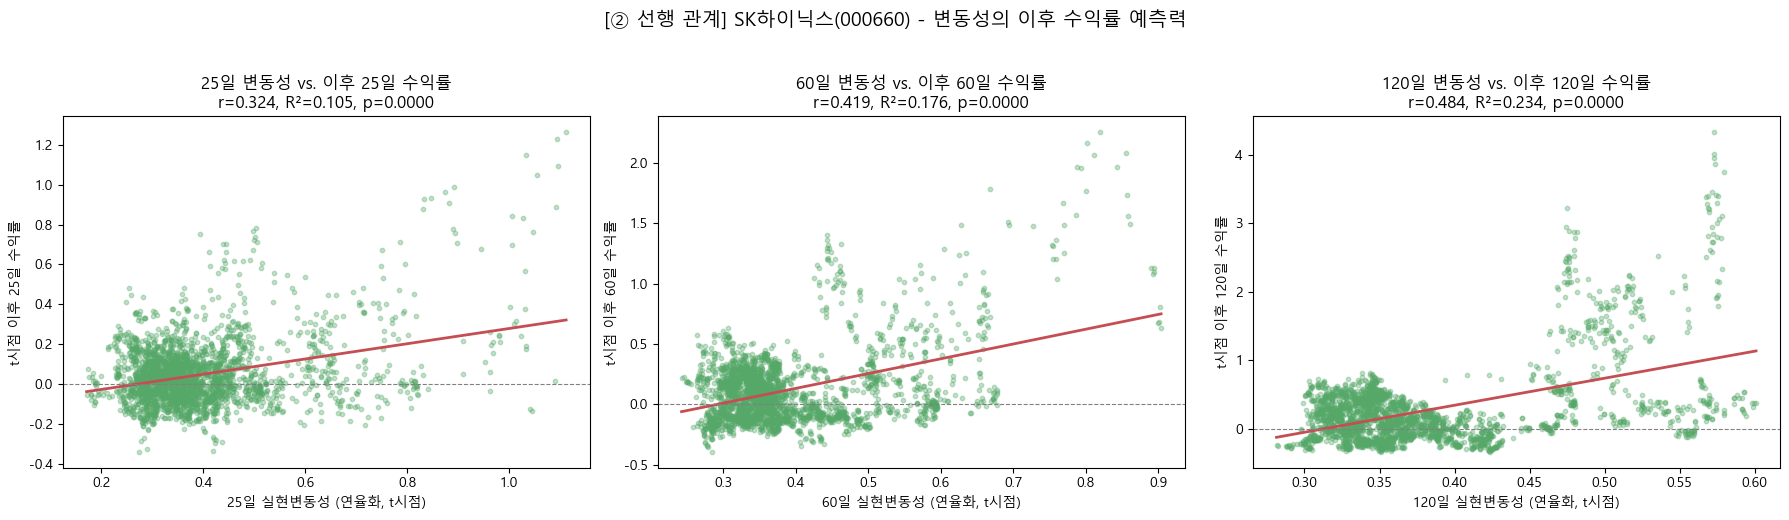

In [55]:
# Cell 8: [시각화 2] 선행(예측) 관계 - 변동성 vs. 이후 N일 수익률 (산점도 + 회귀선)

fig, axes = plt.subplots(1, len(WINDOWS), figsize=(6 * len(WINDOWS), 5), sharey=False)
if len(WINDOWS) == 1:
    axes = [axes]

for ax, w in zip(axes, WINDOWS):
    sub = analysis_df[[f"vol_{w}", f"fwd_ret_{w}"]].dropna()
    x, y = sub[f"vol_{w}"], sub[f"fwd_ret_{w}"]
    row = predictive_stats.loc[w]

    ax.scatter(x, y, s=10, alpha=0.35, color="#55A868")
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, row["intercept"] + row["slope"] * xs, color="#C44E52", linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    ax.set_title(f"{w}일 변동성 vs. 이후 {w}일 수익률\nr={row['pearson_r']:.3f}, R²={row['r_squared']:.3f}, p={row['p_value']:.4f}")
    ax.set_xlabel(f"{w}일 실현변동성 (연율화, t시점)")
    ax.set_ylabel(f"t시점 이후 {w}일 수익률")

fig.suptitle(f"[② 선행 관계] {TICKER_NAME}({TICKER}) - 변동성의 이후 수익률 예측력", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()


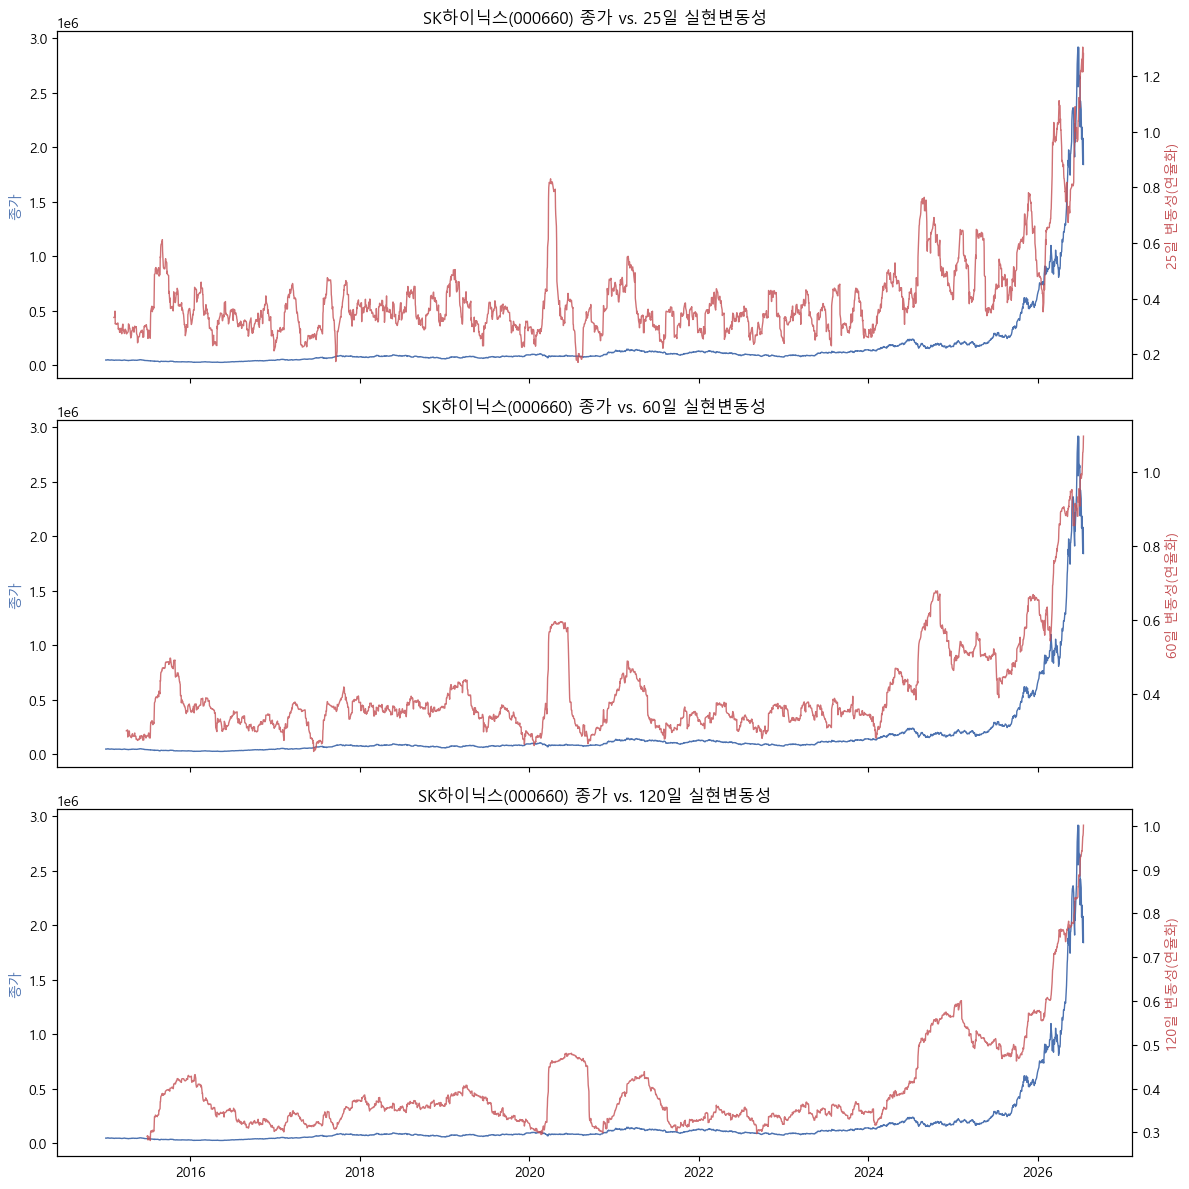

In [56]:
# Cell 9 (선택): 시계열로 변동성과 주가 흐름을 함께 확인 (보조 차트)

fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(12, 4 * len(WINDOWS)), sharex=True)
if len(WINDOWS) == 1:
    axes = [axes]

for ax, w in zip(axes, WINDOWS):
    ax2 = ax.twinx()
    ax.plot(analysis_df.index, analysis_df["Close"], color="#4C72B0", linewidth=1, label="종가")
    ax2.plot(analysis_df.index, analysis_df[f"vol_{w}"], color="#C44E52", linewidth=1, alpha=0.8, label=f"{w}일 변동성")

    ax.set_ylabel("종가", color="#4C72B0")
    ax2.set_ylabel(f"{w}일 변동성(연율화)", color="#C44E52")
    ax.set_title(f"{TICKER_NAME}({TICKER}) 종가 vs. {w}일 실현변동성")

fig.tight_layout()
plt.show()


In [57]:
# Cell 10: 결과 요약 테이블 저장 (선택)

summary = pd.concat(
    {"contemporaneous": contemp_stats, "predictive": predictive_stats},
    axis=0, names=["relation_type", "window"]
)
summary


n_obs  pearson_r  r_squared  p_value  spearman_r  \
relation_type   window                                                     
contemporaneous 25       2807     0.2589     0.0670   0.0000      0.1106   
                60       2772     0.5324     0.2835   0.0000      0.1727   
                120      2712     0.6216     0.3864   0.0000      0.1314   
predictive      25       2782     0.3241     0.1050   0.0000      0.0943   
                60       2712     0.4190     0.1755   0.0000      0.0992   
                120      2592     0.4837     0.2340   0.0000      0.1308   

                        slope  intercept  std_err  
relation_type   window                             
contemporaneous 25     0.2716    -0.0623   0.0191  
                60     1.2233    -0.3746   0.0370  
                120    3.4121    -1.1088   0.0826  
predictive      25     0.3818    -0.1029   0.0211  
                60     1.2250    -0.3580   0.0510  
                120    3.9467    -1.2344   0.1403

---
## 강건성 검증(Robustness Check): 오버래핑 윈도우 편향 보정

위 회귀분석은 **매일 롤링**으로 계산된 `vol_N`, `ret_N`, `fwd_ret_N`을 그대로 사용했습니다.
문제는 N일 윈도우가 하루 간격으로 **서로 심하게 겹친다는 점**입니다. 예를 들어 120일 윈도우는
`n_obs`가 2,000개가 넘게 찍혀도, 실제 독립적인 정보량은 `n_obs / 120` 수준(약 20개 남짓)에
불과합니다. 이 자기상관 때문에:

- 회귀의 표준오차/p-value가 실제보다 훨씬 작게(과대 유의) 나옵니다
- 상관계수 자체도 특정 구간(예: 급등장)의 영향을 과도하게 받을 수 있습니다

**해결 방법**: N일마다 한 번씩만 표본을 추출해 윈도우가 겹치지 않게 만듭니다. 다만 표본 추출을
어디서 시작하느냐(offset)에 따라 결과가 달라질 수 있으므로, **가능한 모든 시작점(0 ~ N-1)에서
각각 비중첩 표본을 만들어 회귀를 반복하고, 그 결과의 분포(평균/중앙값/범위/유의 비율)를 확인**합니다.
이렇게 하면 원래의 오버래핑 결과가 우연한 표본 선택에 좌우된 것인지, 아니면 강건한 관계인지 판단할 수 있습니다.


In [58]:
# Cell 11: 비중첩(non-overlapping) 윈도우 강건성 검증 함수

def nonoverlapping_robust_stats(df: pd.DataFrame, windows: list[int], y_prefix: str,
                                 min_obs: int = 10) -> pd.DataFrame:
    """
    각 윈도우 w에 대해, 0~w-1의 모든 시작 offset에서 w일 간격으로 비중첩 표본을 추출한 뒤
    회귀분석을 반복 수행하고, 그 결과(r, R², p-value)의 분포를 요약합니다.
    """
    results = []
    for w in windows:
        sub = df[[f"vol_{w}", f"{y_prefix}_{w}"]].dropna().reset_index(drop=True)

        r_list, r2_list, p_list, n_list, slope_list = [], [], [], [], []
        for offset in range(w):
            samp = sub.iloc[offset::w]
            if len(samp) < min_obs:
                continue
            x, y = samp[f"vol_{w}"].values, samp[f"{y_prefix}_{w}"].values
            slope, intercept, r, p, se = stats.linregress(x, y)
            r_list.append(r)
            r2_list.append(r ** 2)
            p_list.append(p)
            n_list.append(len(samp))
            slope_list.append(slope)

        r_arr, p_arr = np.array(r_list), np.array(p_list)
        results.append({
            "window": w,
            "n_offsets_tested": len(r_list),
            "avg_n_obs_per_offset": np.mean(n_list),
            "mean_r": r_arr.mean(),
            "median_r": np.median(r_arr),
            "r_min": r_arr.min(),
            "r_max": r_arr.max(),
            "mean_r_squared": np.mean(r2_list),
            "mean_slope": np.mean(slope_list),
            "pct_offsets_significant(p<0.05)": (p_arr < 0.05).mean() * 100,
        })
    return pd.DataFrame(results).set_index("window")


contemp_robust = nonoverlapping_robust_stats(analysis_df, WINDOWS, "ret")
predictive_robust = nonoverlapping_robust_stats(analysis_df, WINDOWS, "fwd_ret")

print("=" * 90)
print("① 동시기 관계 - 비중첩 윈도우 강건성 검증 (offset 0~N-1 전체 결과의 분포)")
print("=" * 90)
display(contemp_robust)

print()
print("=" * 90)
print("② 선행 관계 - 비중첩 윈도우 강건성 검증 (offset 0~N-1 전체 결과의 분포)")
print("=" * 90)
display(predictive_robust)


① 동시기 관계 - 비중첩 윈도우 강건성 검증 (offset 0~N-1 전체 결과의 분포)


,n_offsets_tested,avg_n_obs_per_offset,mean_r,median_r,r_min,r_max,mean_r_squared,mean_slope,pct_offsets_significant(p<0.05)
window,,,,,,,,,
25,25,112.2800,0.2628,0.2539,0.2078,0.3563,0.0706,0.2759,100.0000
60,60,46.2000,0.5319,0.5382,0.3843,0.6286,0.2874,1.2412,100.0000
120,120,22.6000,0.6093,0.5999,0.3766,0.7925,0.3819,3.4178,95.8333



② 선행 관계 - 비중첩 윈도우 강건성 검증 (offset 0~N-1 전체 결과의 분포)


,n_offsets_tested,avg_n_obs_per_offset,mean_r,median_r,r_min,r_max,mean_r_squared,mean_slope,pct_offsets_significant(p<0.05)
window,,,,,,,,,
25,25,111.2800,0.3247,0.3219,0.2278,0.4090,0.1080,0.3875,100.0000
60,60,45.2000,0.3979,0.3971,0.1077,0.5972,0.1819,1.1734,76.6667
120,120,21.6000,0.4558,0.4388,0.1842,0.6985,0.2392,3.7225,54.1667


In [59]:
# Cell 12: 원래(오버래핑) 결과 vs. 비중첩 강건성 검증 결과 비교

def build_comparison(orig_stats: pd.DataFrame, robust_stats: pd.DataFrame) -> pd.DataFrame:
    comp = pd.DataFrame({
        "overlap_r": orig_stats["pearson_r"],
        "overlap_p": orig_stats["p_value"],
        "overlap_n_obs": orig_stats["n_obs"],
        "nonoverlap_mean_r": robust_stats["mean_r"],
        "nonoverlap_r_range": list(zip(robust_stats["r_min"].round(3), robust_stats["r_max"].round(3))),
        "nonoverlap_pct_sig": robust_stats["pct_offsets_significant(p<0.05)"],
        "nonoverlap_avg_n_obs": robust_stats["avg_n_obs_per_offset"],
    })
    return comp


print("[① 동시기 관계] 오버래핑 vs. 비중첩 비교")
comp_contemp = build_comparison(contemp_stats, contemp_robust)
display(comp_contemp)

print()
print("[② 선행 관계] 오버래핑 vs. 비중첩 비교")
comp_predictive = build_comparison(predictive_stats, predictive_robust)
display(comp_predictive)

print()
print("해석 가이드:")
print("  - nonoverlap_mean_r 이 overlap_r 과 비슷한 부호/크기를 유지 -> 관계가 강건함")
print("  - nonoverlap_r_range 가 매우 넓거나 부호가 뒤집힘 -> 원래 결과가 특정 구간(offset)에 좌우된 것일 수 있음")
print("  - nonoverlap_pct_sig 가 낮음 (예: <50%) -> 오버래핑 결과의 p=0.0000은 자기상관으로 인한 과대 유의일 가능성 높음")
print("  - nonoverlap_avg_n_obs 가 매우 작음 (특히 120일) -> 애초에 독립 표본이 부족해 통계적 결론 자체에 주의 필요")


[① 동시기 관계] 오버래핑 vs. 비중첩 비교


,overlap_r,overlap_p,overlap_n_obs,nonoverlap_mean_r,nonoverlap_r_range,nonoverlap_pct_sig,nonoverlap_avg_n_obs
window,,,,,,,
25,0.2589,0.0000,2807,0.2628,"(0.208, 0.356)",100.0000,112.2800
60,0.5324,0.0000,2772,0.5319,"(0.384, 0.629)",100.0000,46.2000
120,0.6216,0.0000,2712,0.6093,"(0.377, 0.793)",95.8333,22.6000



[② 선행 관계] 오버래핑 vs. 비중첩 비교


,overlap_r,overlap_p,overlap_n_obs,nonoverlap_mean_r,nonoverlap_r_range,nonoverlap_pct_sig,nonoverlap_avg_n_obs
window,,,,,,,
25,0.3241,0.0000,2782,0.3247,"(0.228, 0.409)",100.0000,111.2800
60,0.4190,0.0000,2712,0.3979,"(0.108, 0.597)",76.6667,45.2000
120,0.4837,0.0000,2592,0.4558,"(0.184, 0.698)",54.1667,21.6000



해석 가이드:
  - nonoverlap_mean_r 이 overlap_r 과 비슷한 부호/크기를 유지 -> 관계가 강건함
  - nonoverlap_r_range 가 매우 넓거나 부호가 뒤집힘 -> 원래 결과가 특정 구간(offset)에 좌우된 것일 수 있음
  - nonoverlap_pct_sig 가 낮음 (예: <50%) -> 오버래핑 결과의 p=0.0000은 자기상관으로 인한 과대 유의일 가능성 높음
  - nonoverlap_avg_n_obs 가 매우 작음 (특히 120일) -> 애초에 독립 표본이 부족해 통계적 결론 자체에 주의 필요


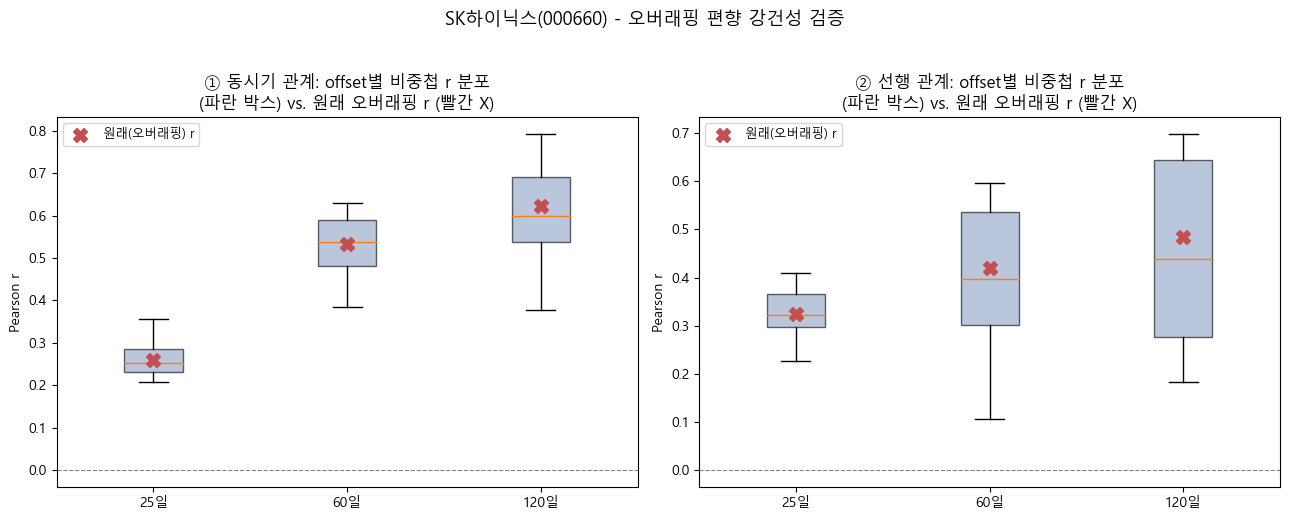

In [60]:
# Cell 13: [시각화 3] 오버래핑 vs. 비중첩(offset별 분포) 비교 - 박스플롯

def collect_offset_r_values(df: pd.DataFrame, windows: list[int], y_prefix: str, min_obs: int = 10):
    out = {}
    for w in windows:
        sub = df[[f"vol_{w}", f"{y_prefix}_{w}"]].dropna().reset_index(drop=True)
        r_list = []
        for offset in range(w):
            samp = sub.iloc[offset::w]
            if len(samp) < min_obs:
                continue
            x, y = samp[f"vol_{w}"].values, samp[f"{y_prefix}_{w}"].values
            _, _, r, _, _ = stats.linregress(x, y)
            r_list.append(r)
        out[w] = r_list
    return out


contemp_r_dist = collect_offset_r_values(analysis_df, WINDOWS, "ret")
predictive_r_dist = collect_offset_r_values(analysis_df, WINDOWS, "fwd_ret")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, r_dist, orig_stats, title in [
    (axes[0], contemp_r_dist, contemp_stats, "① 동시기 관계"),
    (axes[1], predictive_r_dist, predictive_stats, "② 선행 관계"),
]:
    data = [r_dist[w] for w in WINDOWS]
    bp = ax.boxplot(data, labels=[f"{w}일" for w in WINDOWS], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#8CA0C6")
        patch.set_alpha(0.6)

    # 원래(오버래핑) r 값을 빨간 점(X)으로 함께 표시
    for i, w in enumerate(WINDOWS, start=1):
        ax.scatter(i, orig_stats.loc[w, "pearson_r"], color="#C44E52", marker="X", s=100, zorder=5,
                   label="원래(오버래핑) r" if i == 1 else None)

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(f"{title}: offset별 비중첩 r 분포\n(파란 박스) vs. 원래 오버래핑 r (빨간 X)")
    ax.set_ylabel("Pearson r")
    ax.legend(loc="best", fontsize=9)

fig.suptitle(f"{TICKER_NAME}({TICKER}) - 오버래핑 편향 강건성 검증", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()


---
## 구간 분할(Regime Split) 분석

전체 표본 기간을 하나로 묶어 회귀분석을 하면, 특정 국면(예: 2024~2026 AI/반도체 급등장)이
전체 상관계수를 지배할 수 있습니다. 이를 확인하기 위해 두 가지 방식으로 구간을 나눠 같은 관계 분석을
반복합니다.

1. **고정 날짜 분할**: `REGIME_SPLIT_DATE`(기본 2024-01-01) 이전 vs. 이후로 단순 비교
2. **추세 기반 자동 강세장/약세장 분류**: 표준적인 "20% 룰"을 사용해 고점 대비 `REGIME_DD_THRESHOLD`(기본 20%)
   이상 하락하면 약세장 국면 시작, 저점 대비 20% 이상 반등하면 강세장 국면 시작으로 자동 분류합니다.
   (최소 지속기간 필터는 적용하지 않은 단순 버전이므로, 짧은 급등락에도 국면이 바뀔 수 있다는 점 참고)


In [61]:
# Cell 14: 추세 기반 강세장/약세장 자동 분류 (20% 룰)

def classify_bull_bear(prices: pd.Series, threshold: float = 0.20) -> pd.Series:
    """
    표준적인 20% 룰: 고점 대비 -threshold 하락하면 약세장(bear) 진입,
    저점 대비 +threshold 반등하면 강세장(bull) 진입으로 분류합니다.
    """
    state_list = []
    state = "bull"  # 표본 시작 시점은 강세장으로 가정
    peak = prices.iloc[0]
    trough = prices.iloc[0]

    for p in prices:
        if state == "bull":
            if p > peak:
                peak = p
            if p <= peak * (1 - threshold):
                state = "bear"
                trough = p
        else:  # state == "bear"
            if p < trough:
                trough = p
            if p >= trough * (1 + threshold):
                state = "bull"
                peak = p
        state_list.append(state)

    return pd.Series(state_list, index=prices.index, name="regime")


def summarize_regime_episodes(regime: pd.Series, prices: pd.Series) -> pd.DataFrame:
    """연속된 강세장/약세장 구간(episode)별로 시작일, 종료일, 일수, 구간 수익률을 요약"""
    episode_id = (regime != regime.shift()).cumsum()
    rows = []
    for _, grp in regime.groupby(episode_id):
        start_date, end_date = grp.index[0], grp.index[-1]
        start_price, end_price = prices.loc[start_date], prices.loc[end_date]
        rows.append({
            "regime": grp.iloc[0],
            "start": start_date.date(),
            "end": end_date.date(),
            "n_days": len(grp),
            "period_return": end_price / start_price - 1,
        })
    return pd.DataFrame(rows)


analysis_df["regime"] = classify_bull_bear(analysis_df["Close"], REGIME_DD_THRESHOLD)

regime_episodes = summarize_regime_episodes(analysis_df["regime"], analysis_df["Close"])
print(f"강세장/약세장 국면 수: 총 {len(regime_episodes)}개 "
      f"(강세장 {(regime_episodes['regime']=='bull').sum()}개, 약세장 {(regime_episodes['regime']=='bear').sum()}개)")
print(f"전체 표본 중 강세장 일수 비중: {(analysis_df['regime']=='bull').mean()*100:.1f}%")
display(regime_episodes)


강세장/약세장 국면 수: 총 32개 (강세장 16개, 약세장 16개)
전체 표본 중 강세장 일수 비중: 74.5%


,regime,start,end,n_days,period_return
0,bull,2015-01-02,2015-07-03,125,-0.1068
1,bear,2015-07-06,2015-10-06,64,-0.0871
2,bull,2015-10-07,2015-12-10,46,-0.1877
3,bear,2015-12-11,2016-03-02,52,0.0369
4,bull,2016-03-03,2018-01-19,464,1.2942
5,bear,2018-01-22,2018-03-09,32,0.1716
6,bull,2018-03-12,2018-08-09,104,-0.0813
7,bear,2018-08-10,2019-01-23,110,-0.1105
8,bull,2019-01-24,2019-05-30,85,-0.0652
9,bear,2019-05-31,2019-07-12,30,0.1440


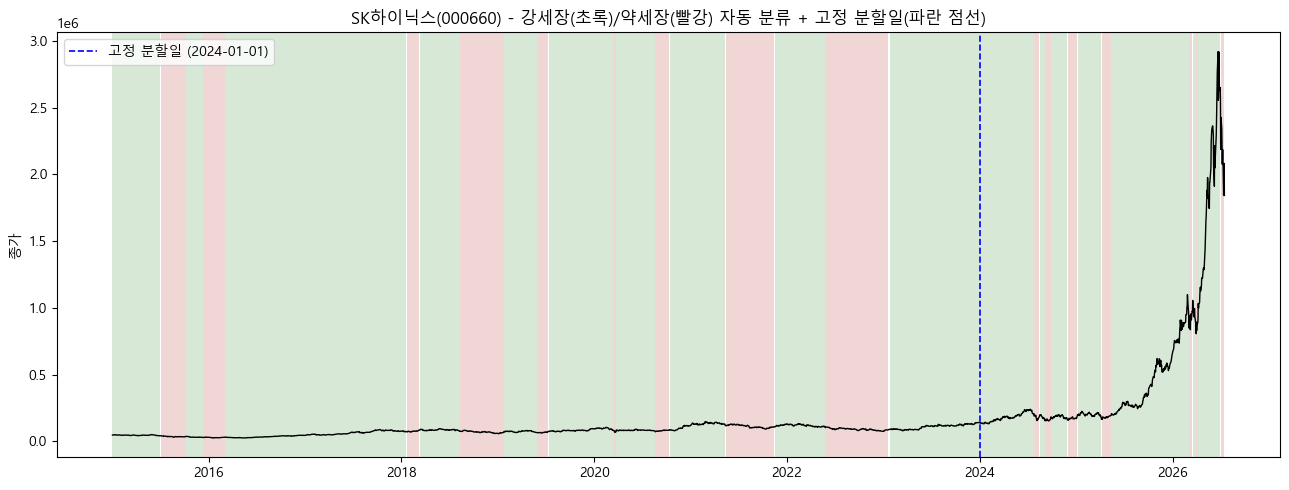

In [62]:
# Cell 15: [시각화 4] 주가 차트 위에 강세장/약세장 국면 음영 표시

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(analysis_df.index, analysis_df["Close"], color="black", linewidth=1)

for _, row in regime_episodes.iterrows():
    color = "#8fbf8f" if row["regime"] == "bull" else "#d98c8c"
    ax.axvspan(row["start"], row["end"], color=color, alpha=0.35, linewidth=0)

# 고정 날짜 분할선도 함께 표시
ax.axvline(pd.Timestamp(REGIME_SPLIT_DATE), color="blue", linestyle="--", linewidth=1.2,
           label=f"고정 분할일 ({REGIME_SPLIT_DATE})")

ax.set_title(f"{TICKER_NAME}({TICKER}) - 강세장(초록)/약세장(빨강) 자동 분류 + 고정 분할일(파란 점선)")
ax.set_ylabel("종가")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


In [63]:
# Cell 16: 구간별(전체/고정분할/강세장·약세장) 관계 분석 비교

def stats_for_groups(df: pd.DataFrame, windows: list[int], y_prefix: str,
                      groups: dict) -> pd.DataFrame:
    """groups = {그룹이름: boolean mask 또는 None(전체)} 형태로 받아 각 그룹별 relationship_stats를 이어붙임"""
    pieces = []
    for name, mask in groups.items():
        sub_df = df if mask is None else df[mask]
        s = relationship_stats(sub_df, windows, y_prefix)
        s["group"] = name
        pieces.append(s)
    return pd.concat(pieces).reset_index().set_index(["group", "window"])


pre_mask = analysis_df.index < pd.Timestamp(REGIME_SPLIT_DATE)
post_mask = analysis_df.index >= pd.Timestamp(REGIME_SPLIT_DATE)
bull_mask = analysis_df["regime"] == "bull"
bear_mask = analysis_df["regime"] == "bear"

groups = {
    "전체": None,
    f"{REGIME_SPLIT_DATE} 이전": pre_mask,
    f"{REGIME_SPLIT_DATE} 이후": post_mask,
    "강세장": bull_mask,
    "약세장": bear_mask,
}

contemp_by_group = stats_for_groups(analysis_df, WINDOWS, "ret", groups)
predictive_by_group = stats_for_groups(analysis_df, WINDOWS, "fwd_ret", groups)

print("=" * 90)
print("① 동시기 관계 - 구간별 비교 (전체 / 고정분할 전후 / 강세장·약세장)")
print("=" * 90)
display(contemp_by_group[["n_obs", "pearson_r", "r_squared", "p_value"]])

print()
print("=" * 90)
print("② 선행 관계 - 구간별 비교 (전체 / 고정분할 전후 / 강세장·약세장)")
print("=" * 90)
display(predictive_by_group[["n_obs", "pearson_r", "r_squared", "p_value"]])


① 동시기 관계 - 구간별 비교 (전체 / 고정분할 전후 / 강세장·약세장)


n_obs  pearson_r  r_squared  p_value
group         window                                      
전체            25       2807     0.2589     0.0670   0.0000
              60       2772     0.5324     0.2835   0.0000
              120      2712     0.6216     0.3864   0.0000
2024-01-01 이전 25       2189    -0.0483     0.0023   0.0238
              60       2154    -0.1206     0.0146   0.0000
              120      2094    -0.1714     0.0294   0.0000
2024-01-01 이후 25        618     0.1393     0.0194   0.0005
              60        618     0.5496     0.3020   0.0000
              120       618     0.6105     0.3727   0.0000
강세장           25       2085     0.3784     0.1432   0.0000
              60       2050     0.5333     0.2845   0.0000
              120      1990     0.6270     0.3931   0.0000
약세장           25        722    -0.0496     0.0025   0.1829
              60        722     0.6635     0.4403   0.0000
              120       722     0.7460     0.5565   0.0000


② 선행 관계 - 구간별 비교 (전체 / 고정분할 전후 / 강세장·약세장)


n_obs  pearson_r  r_squared  p_value
group         window                                      
전체            25       2782     0.3241     0.1050   0.0000
              60       2712     0.4190     0.1755   0.0000
              120      2592     0.4837     0.2340   0.0000
2024-01-01 이전 25       2189    -0.0462     0.0021   0.0306
              60       2154    -0.1990     0.0396   0.0000
              120      2094    -0.0437     0.0019   0.0457
2024-01-01 이후 25        593     0.2950     0.0871   0.0000
              60        558     0.4123     0.1700   0.0000
              120       498     0.3570     0.1275   0.0000
강세장           25       2071     0.2712     0.0736   0.0000
              60       2001     0.3600     0.1296   0.0000
              120      1897     0.4808     0.2312   0.0000
약세장           25        711     0.4830     0.2333   0.0000
              60        711     0.5841     0.3412   0.0000
              120       695     0.5217     0.2722   0.0000

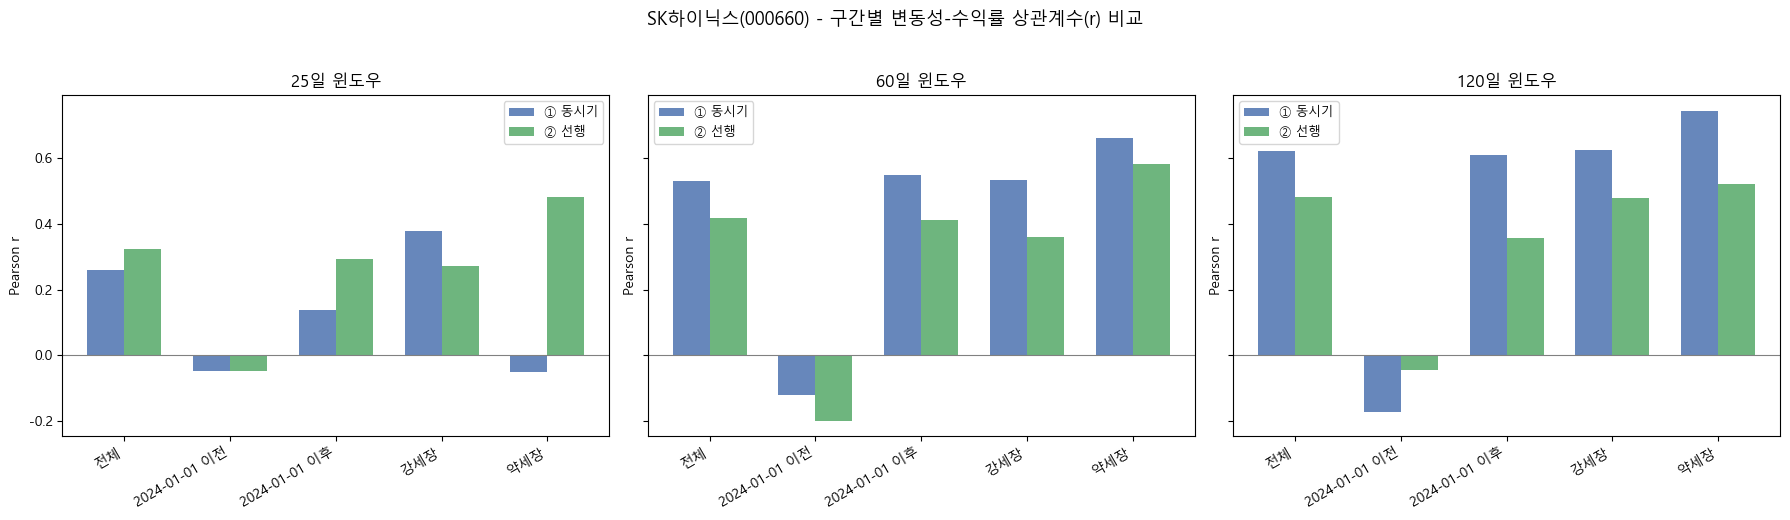

In [64]:
# Cell 17: [시각화 5] 구간별 상관계수(r) 비교 막대그래프

group_order = ["전체", f"{REGIME_SPLIT_DATE} 이전", f"{REGIME_SPLIT_DATE} 이후", "강세장", "약세장"]
group_colors = {"전체": "#888888", f"{REGIME_SPLIT_DATE} 이전": "#4C72B0", f"{REGIME_SPLIT_DATE} 이후": "#DD8452",
                "강세장": "#55A868", "약세장": "#C44E52"}

fig, axes = plt.subplots(1, len(WINDOWS), figsize=(6 * len(WINDOWS), 5), sharey=True)
if len(WINDOWS) == 1:
    axes = [axes]

width = 0.35
x = np.arange(len(group_order))

for ax, w in zip(axes, WINDOWS):
    contemp_r = [contemp_by_group.loc[(g, w), "pearson_r"] for g in group_order]
    predictive_r = [predictive_by_group.loc[(g, w), "pearson_r"] for g in group_order]

    ax.bar(x - width / 2, contemp_r, width, label="① 동시기", color="#4C72B0", alpha=0.85)
    ax.bar(x + width / 2, predictive_r, width, label="② 선행", color="#55A868", alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(group_order, rotation=30, ha="right")
    ax.set_title(f"{w}일 윈도우")
    ax.set_ylabel("Pearson r")
    ax.legend(loc="best", fontsize=9)

fig.suptitle(f"{TICKER_NAME}({TICKER}) - 구간별 변동성-수익률 상관계수(r) 비교", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()


---
## 국면 고정효과(Regime Fixed-Effects) 분석 — 심슨의 역설 검증

구간 분할 분석에서 "전체 표본(강세장+약세장 혼합)"에서는 상관관계가 약하거나 사라지는데,
강세장/약세장을 각각 따로 모아 보면 상관관계가 살아나는 패턴이 나타날 수 있습니다.
이는 국면별 **평균 수준(레벨) 차이**가 전체 상관관계를 가리는 심슨의 역설(Simpson's Paradox)
때문일 수 있습니다.

이를 확인하기 위해 각 국면(bull/bear episode)마다 변동성과 수익률의 **국면 내 평균을 빼고(demean)**,
그 편차(국면 내 변동)만으로 회귀분석을 다시 수행합니다. 이는 계량경제학의
**고정효과(Fixed-Effects, Within Estimator) 회귀**와 동일한 방법입니다.

- `pooled_r` (기존 전체 표본 상관계수): 국면 간 레벨 차이 + 국면 내 변동이 모두 섞인 결과
- `within_r` (국면 고정효과 상관계수): 국면 간 레벨 차이를 제거하고, 순수하게 "같은 국면 안에서
  변동성이 오르내릴 때 수익률이 같이 움직이는지"만 측정한 결과

두 값이 비슷하면 관계가 강건한 것이고, `within_r`이 `pooled_r`보다 뚜렷이 크거나(혹은 부호가
바뀌거나) 하면 심슨의 역설이 실제로 작동하고 있다는 뜻입니다.

⚠️ 유의사항: `vol_N`, `ret_N`은 롤링 윈도우라서 국면 경계 근처에서는 창(window) 안에 이전 국면의
날짜가 섞여 들어갑니다. 이 오염을 줄이기 위해 국면 내 관측치가 `MIN_EPISODE_OBS`(기본 60일)
미만인 국면은 분석에서 제외합니다.


In [65]:
# Cell 18: 국면 고정효과(Fixed-Effects / Within Estimator) 회귀분석

analysis_df["episode_id"] = (analysis_df["regime"] != analysis_df["regime"].shift()).cumsum()


def fixed_effects_stats(df: pd.DataFrame, windows: list[int], y_prefix: str,
                         episode_col: str = "episode_id", min_episode_obs: int = 60) -> pd.DataFrame:
    """
    각 윈도우 w에 대해 국면(episode)별로 vol_w, {y_prefix}_w의 국면 내 평균을 빼고(demean),
    그 편차만으로 회귀분석을 수행합니다 (고정효과/within estimator와 동일).
    """
    rows = []
    for w in windows:
        sub = df[[f"vol_{w}", f"{y_prefix}_{w}", episode_col]].dropna().copy()

        counts = sub[episode_col].value_counts()
        valid_ids = counts[counts >= min_episode_obs].index
        excluded_n = counts[~counts.index.isin(valid_ids)].shape[0]
        sub = sub[sub[episode_col].isin(valid_ids)]

        sub["vol_demean"] = sub[f"vol_{w}"] - sub.groupby(episode_col)[f"vol_{w}"].transform("mean")
        sub["y_demean"] = sub[f"{y_prefix}_{w}"] - sub.groupby(episode_col)[f"{y_prefix}_{w}"].transform("mean")

        x, y = sub["vol_demean"].values, sub["y_demean"].values
        slope, intercept, r, p, se = stats.linregress(x, y)

        rows.append({
            "window": w,
            "n_obs": len(sub),
            "n_episodes_used": sub[episode_col].nunique(),
            "n_episodes_excluded": excluded_n,
            "within_r": r,
            "within_r_squared": r ** 2,
            "within_p_value": p,
            "within_slope": slope,
        })
    return pd.DataFrame(rows).set_index("window")


contemp_fe = fixed_effects_stats(analysis_df, WINDOWS, "ret", min_episode_obs=MIN_EPISODE_OBS)
predictive_fe = fixed_effects_stats(analysis_df, WINDOWS, "fwd_ret", min_episode_obs=MIN_EPISODE_OBS)

print("=" * 90)
print("① 동시기 관계 - 국면 고정효과(within) 회귀 결과")
print("=" * 90)
display(contemp_fe)

print()
print("=" * 90)
print("② 선행 관계 - 국면 고정효과(within) 회귀 결과")
print("=" * 90)
display(predictive_fe)


① 동시기 관계 - 국면 고정효과(within) 회귀 결과


,n_obs,n_episodes_used,n_episodes_excluded,within_r,within_r_squared,within_p_value,within_slope
window,,,,,,,
25,2381,15,17,0.0669,0.0045,0.0011,0.0936
60,2346,15,17,0.1455,0.0212,0.0000,0.4672
120,2281,14,18,0.3788,0.1435,0.0000,4.1512



② 선행 관계 - 국면 고정효과(within) 회귀 결과


,n_obs,n_episodes_used,n_episodes_excluded,within_r,within_r_squared,within_p_value,within_slope
window,,,,,,,
25,2381,15,16,-0.0809,0.0065,0.0001,-0.1234
60,2346,15,16,-0.2055,0.0422,0.0000,-0.7319
120,2254,14,13,-0.0884,0.0078,0.0000,-0.9509


In [66]:
# Cell 19: pooled(전체) vs. within(국면 고정효과) 비교

def compare_pooled_vs_within(pooled_stats: pd.DataFrame, fe_stats: pd.DataFrame) -> pd.DataFrame:
    comp = pd.DataFrame({
        "pooled_r": pooled_stats["pearson_r"],
        "pooled_p": pooled_stats["p_value"],
        "within_r": fe_stats["within_r"],
        "within_p": fe_stats["within_p_value"],
        "within_n_obs": fe_stats["n_obs"],
        "n_episodes_used": fe_stats["n_episodes_used"],
        "n_episodes_excluded": fe_stats["n_episodes_excluded"],
    })
    comp["r_gap(within-pooled)"] = comp["within_r"] - comp["pooled_r"]
    return comp


print("[① 동시기 관계] pooled(전체) vs. within(국면 고정효과)")
comp_contemp_fe = compare_pooled_vs_within(contemp_stats, contemp_fe)
display(comp_contemp_fe)

print()
print("[② 선행 관계] pooled(전체) vs. within(국면 고정효과)")
comp_predictive_fe = compare_pooled_vs_within(predictive_stats, predictive_fe)
display(comp_predictive_fe)

print()
print("해석 가이드:")
print("  - within_r 이 pooled_r 과 비슷하거나 더 큼 -> 국면 내부에서도 관계가 살아있음 (진짜 관계)")
print("  - within_r 이 pooled_r 보다 훨씬 작거나 유의성이 사라짐 -> 원래 상관관계가 국면 간 레벨 차이(심슨의 역설)에서 비롯된 것")
print("  - within_r 부호가 pooled_r 과 반대 -> 국면 내부 관계는 오히려 반대 방향일 수 있음 (전형적 심슨의 역설)")


[① 동시기 관계] pooled(전체) vs. within(국면 고정효과)


,pooled_r,pooled_p,within_r,within_p,within_n_obs,n_episodes_used,n_episodes_excluded,r_gap(within-pooled)
window,,,,,,,,
25,0.2589,0.0000,0.0669,0.0011,2381,15,17,-0.1920
60,0.5324,0.0000,0.1455,0.0000,2346,15,17,-0.3869
120,0.6216,0.0000,0.3788,0.0000,2281,14,18,-0.2428



[② 선행 관계] pooled(전체) vs. within(국면 고정효과)


,pooled_r,pooled_p,within_r,within_p,within_n_obs,n_episodes_used,n_episodes_excluded,r_gap(within-pooled)
window,,,,,,,,
25,0.3241,0.0000,-0.0809,0.0001,2381,15,16,-0.4050
60,0.4190,0.0000,-0.2055,0.0000,2346,15,16,-0.6244
120,0.4837,0.0000,-0.0884,0.0000,2254,14,13,-0.5722



해석 가이드:
  - within_r 이 pooled_r 과 비슷하거나 더 큼 -> 국면 내부에서도 관계가 살아있음 (진짜 관계)
  - within_r 이 pooled_r 보다 훨씬 작거나 유의성이 사라짐 -> 원래 상관관계가 국면 간 레벨 차이(심슨의 역설)에서 비롯된 것
  - within_r 부호가 pooled_r 과 반대 -> 국면 내부 관계는 오히려 반대 방향일 수 있음 (전형적 심슨의 역설)


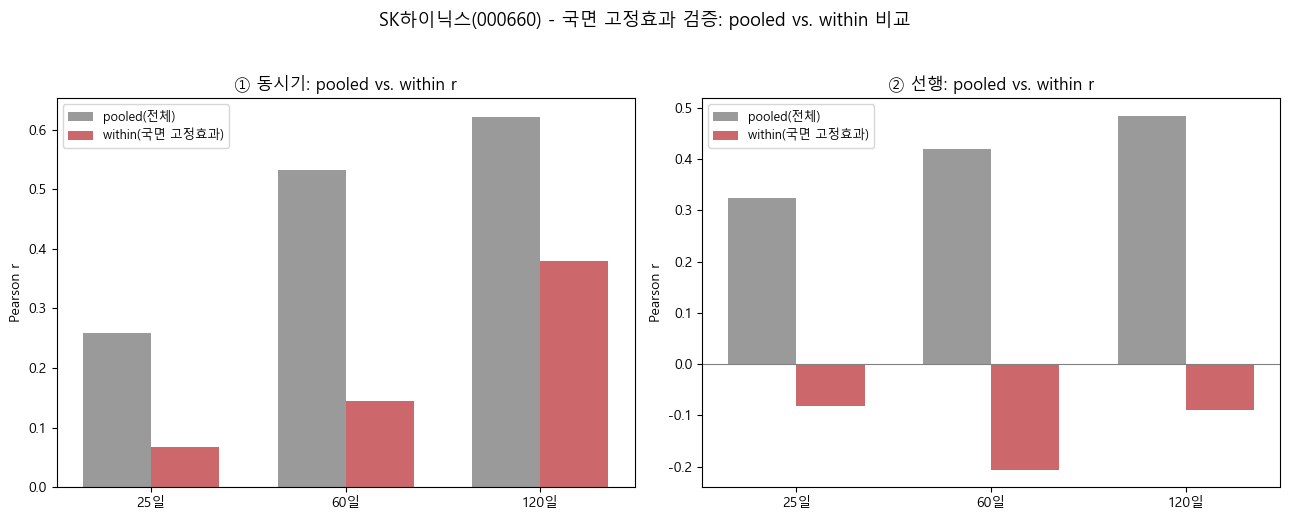

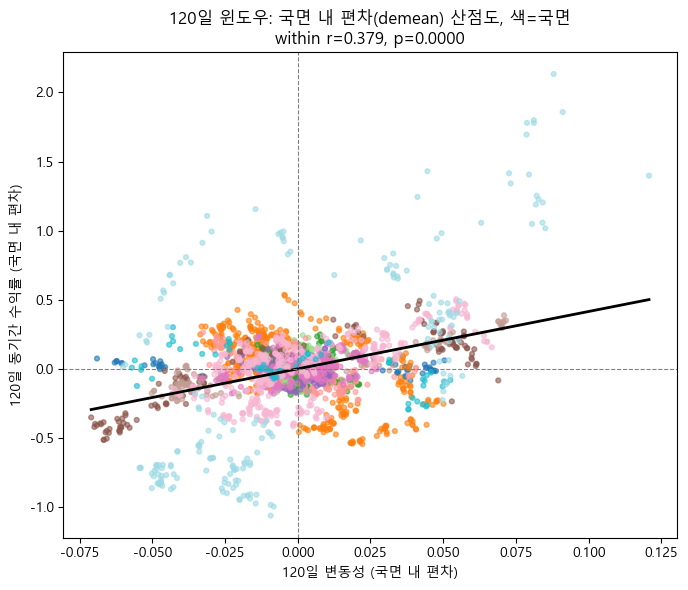

In [67]:
# Cell 20: [시각화 6] pooled vs. within r 비교 막대그래프 + 국면별 색상 산점도(대표 윈도우)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comp_list = [("① 동시기", comp_contemp_fe), ("② 선행", comp_predictive_fe)]
width = 0.35
xw = np.arange(len(WINDOWS))

for ax, (title, comp) in zip(axes, comp_list):
    ax.bar(xw - width / 2, comp["pooled_r"], width, label="pooled(전체)", color="#888888", alpha=0.85)
    ax.bar(xw + width / 2, comp["within_r"], width, label="within(국면 고정효과)", color="#C44E52", alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(xw)
    ax.set_xticklabels([f"{w}일" for w in WINDOWS])
    ax.set_title(f"{title}: pooled vs. within r")
    ax.set_ylabel("Pearson r")
    ax.legend(loc="best", fontsize=9)

fig.suptitle(f"{TICKER_NAME}({TICKER}) - 국면 고정효과 검증: pooled vs. within 비교", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()


# 대표 윈도우(가장 긴 윈도우) 하나를 골라, 국면별 색상으로 demean 산점도를 그려 within 관계를 직접 확인
w_rep = WINDOWS[-1]
sub_rep = analysis_df[[f"vol_{w_rep}", f"ret_{w_rep}", "episode_id"]].dropna().copy()
counts_rep = sub_rep["episode_id"].value_counts()
valid_ids_rep = counts_rep[counts_rep >= MIN_EPISODE_OBS].index
sub_rep = sub_rep[sub_rep["episode_id"].isin(valid_ids_rep)]
sub_rep["vol_demean"] = sub_rep[f"vol_{w_rep}"] - sub_rep.groupby("episode_id")[f"vol_{w_rep}"].transform("mean")
sub_rep["ret_demean"] = sub_rep[f"ret_{w_rep}"] - sub_rep.groupby("episode_id")[f"ret_{w_rep}"].transform("mean")

fig2, ax2 = plt.subplots(figsize=(7, 6))
sc = ax2.scatter(sub_rep["vol_demean"], sub_rep["ret_demean"], c=sub_rep["episode_id"],
                  cmap="tab20", s=12, alpha=0.6)
slope_r, intercept_r, r_r, p_r, se_r = stats.linregress(sub_rep["vol_demean"], sub_rep["ret_demean"])
xs = np.linspace(sub_rep["vol_demean"].min(), sub_rep["vol_demean"].max(), 100)
ax2.plot(xs, intercept_r + slope_r * xs, color="black", linewidth=2)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_title(f"{w_rep}일 윈도우: 국면 내 편차(demean) 산점도, 색=국면\nwithin r={r_r:.3f}, p={p_r:.4f}")
ax2.set_xlabel(f"{w_rep}일 변동성 (국면 내 편차)")
ax2.set_ylabel(f"{w_rep}일 동기간 수익률 (국면 내 편차)")
fig2.tight_layout()
plt.show()


---
## 유사 국면(Analog) 탐색: "지금과 비슷했던 과거, 그 이후엔?"

현재 시점의 `(25/60/120일 변동성, 25/60/120일 수익률)` 6개 지표를 벡터로 놓고, 표준화(z-score)한 뒤
과거 모든 시점과의 유클리드 거리를 계산합니다. 가장 가까운(비슷한) 과거 시점들을 찾아서, 그 시점
**이후** 실제로 25/60/120/250 거래일 동안 주가가 어떻게 움직였는지 확인합니다.

⚠️ **중요한 한계**:
- 이는 미래를 예측하는 모델이 아니라, "과거 유사 사례를 나열해서 참고하는" 순수 기술적 분석입니다.
- 한국 증시 표본(약 11년) 안에서 독립적인 급등 국면 자체가 몇 개 되지 않기 때문에, 찾아낸 유사
  시점들이 실제로는 2~3개의 큰 사건(예: 2017년 랠리, 2020~21년 랠리)에 몰려있을 수 있습니다.
  이 경우 "15개의 사례"가 아니라 사실상 "2~3개의 독립적인 사례"에 가깝다는 점을 감안해야 합니다.
- 투자 조언이 아니며, 과거 패턴이 반복된다는 보장도 없습니다.


In [68]:
# Cell 21: 유사 국면(analog) 탐색 - 현재와 가장 비슷했던 과거 시점 찾기

feat_cols = [f"vol_{w}" for w in WINDOWS] + [f"ret_{w}" for w in WINDOWS]
feat_df = analysis_df[feat_cols].dropna()

# 표준화 (z-score): 전체 표본 기준 평균/표준편차로 스케일 통일
feat_mean, feat_std = feat_df.mean(), feat_df.std()
z_df = (feat_df - feat_mean) / feat_std

# 현재(가장 최근 유효) 시점
current_date = z_df.index[-1]
current_vec = z_df.iloc[-1]

print(f"[현재 시점: {current_date.date()}] 비교 기준 지표")
for w in WINDOWS:
    print(f"  - {w}일: 변동성={analysis_df.loc[current_date, f'vol_{w}']:.4f}, "
          f"수익률={analysis_df.loc[current_date, f'ret_{w}']:.4f}")

# 거래일 위치(포지션) 매핑 - 미래 데이터 확보 및 최근 구간 제외에 사용
price_index = analysis_df.index
pos_map = {d: i for i, d in enumerate(price_index)}
current_pos = pos_map[current_date]
max_horizon = max(ANALOG_FORWARD_HORIZONS)
last_pos = len(price_index) - 1

# 후보 1차 필터: (a) 현재와 너무 가깝지 않고(윈도우 겹침 방지), (b) 이후 max_horizon일 데이터가 존재하는 시점
candidate_dates = [
    d for d in z_df.index
    if pos_map[d] <= current_pos - ANALOG_EXCLUDE_RECENT_DAYS
    and pos_map[d] + max_horizon <= last_pos
]
n_before_direction_filter = len(candidate_dates)

# 후보 2차 필터 (선택): 현재와 수익률 "부호"까지 일치하는 시점만 남김
# 예: 지금이 변동성 상승 + 수익률 상승(멜트업)이면, 과거에 변동성만 비슷하게 튀었던
#     폭락 국면(수익률 마이너스)은 후보에서 제외되어 개념적으로 더 유사한 사례만 비교됨
if ANALOG_REQUIRE_SAME_DIRECTION:
    current_ret_signs = {w: np.sign(analysis_df.loc[current_date, f"ret_{w}"]) for w in WINDOWS}
    candidate_dates = [
        d for d in candidate_dates
        if all(np.sign(analysis_df.loc[d, f"ret_{w}"]) == current_ret_signs[w] for w in WINDOWS)
    ]

print(f"\n방향 필터 적용 전 후보: {n_before_direction_filter}개 -> "
      f"적용 후: {len(candidate_dates)}개 "
      f"(ANALOG_REQUIRE_SAME_DIRECTION={ANALOG_REQUIRE_SAME_DIRECTION})")

candidates = z_df.loc[candidate_dates]

# 유클리드 거리 계산
dist = np.sqrt(((candidates - current_vec) ** 2).sum(axis=1)).sort_values()

# 최소 간격(gap) 제약을 두고 greedy하게 상위 유사 시점 선택
selected_dates = []
for d in dist.index:
    if all(abs(pos_map[d] - pos_map[s]) >= ANALOG_MIN_GAP_DAYS for s in selected_dates):
        selected_dates.append(d)
    if len(selected_dates) >= ANALOG_N_MATCHES:
        break

print(f"선택된 유사 시점: {len(selected_dates)}개 (요청 {ANALOG_N_MATCHES}개 중)")


[현재 시점: 2026-07-16] 비교 기준 지표
  - 25일: 변동성=1.2815, 수익률=-0.1233
  - 60일: 변동성=1.0981, 수익률=0.6330
  - 120일: 변동성=1.0016, 수익률=1.4110

방향 필터 적용 전 후보: 2462개 -> 적용 후: 247개 (ANALOG_REQUIRE_SAME_DIRECTION=True)
선택된 유사 시점: 14개 (요청 15개 중)


In [69]:
# Cell 22: 유사 시점 이후 실제 수익률 집계

rows = []
for d in selected_dates:
    row = {
        "date": d.date(),
        "distance": dist.loc[d],
        "regime": analysis_df.loc[d, "regime"],
        "episode_id": analysis_df.loc[d, "episode_id"],
    }
    for w in WINDOWS:
        row[f"vol_{w}"] = analysis_df.loc[d, f"vol_{w}"]
        row[f"ret_{w}"] = analysis_df.loc[d, f"ret_{w}"]
    base_price = analysis_df["Close"].iloc[pos_map[d]]
    for h in ANALOG_FORWARD_HORIZONS:
        fut_price = analysis_df["Close"].iloc[pos_map[d] + h]
        row[f"fwd_{h}d_ret"] = fut_price / base_price - 1
    rows.append(row)

analog_results = pd.DataFrame(rows).sort_values("distance").reset_index(drop=True)

n_unique_episodes = analog_results["episode_id"].nunique()
print(f"선택된 {len(analog_results)}개 유사 시점이 속한 국면(episode) 수: {n_unique_episodes}개")
if n_unique_episodes < len(analog_results) / 2:
    print("  -> 주의: 유사 시점들이 소수의 국면에 몰려 있습니다. 사실상 독립적인 사례 수는 이보다 적습니다.")

display(analog_results)

print()
print("=" * 70)
print(f"[요약] 유사 과거 시점 이후 {ANALOG_FORWARD_HORIZONS} 거래일 수익률 분포")
print("=" * 70)

summary_rows = []
for h in ANALOG_FORWARD_HORIZONS:
    col = f"fwd_{h}d_ret"
    summary_rows.append({
        "horizon_days": h,
        "n_analogs": analog_results[col].notna().sum(),
        "mean_return": analog_results[col].mean(),
        "median_return": analog_results[col].median(),
        "win_rate(%)": (analog_results[col] > 0).mean() * 100,
        "min_return": analog_results[col].min(),
        "max_return": analog_results[col].max(),
    })
analog_summary = pd.DataFrame(summary_rows).set_index("horizon_days")
display(analog_summary)


선택된 14개 유사 시점이 속한 국면(episode) 수: 9개


,date,distance,regime,episode_id,vol_25,ret_25,vol_60,ret_60,vol_120,ret_120,fwd_25d_ret,fwd_60d_ret,fwd_120d_ret,fwd_250d_ret
0,2024-08-16,7.6964,bull,21,0.7494,-0.1714,0.5677,0.0101,0.5149,0.3403,-0.1723,-0.1402,0.0941,0.3470
1,2025-03-05,8.5451,bull,25,0.5198,-0.1437,0.5097,0.2076,0.5367,0.1379,-0.1455,0.0746,0.3905,4.0440
2,2021-03-30,9.4942,bull,15,0.4592,-0.0147,0.4599,0.1595,0.4194,0.6012,-0.0186,-0.0632,-0.2045,-0.1301
3,2019-04-01,10.0049,bull,9,0.4054,-0.0013,0.4375,0.2661,0.4037,0.0683,0.0483,-0.0836,0.0888,0.0444
4,2017-11-07,10.2367,bull,5,0.4433,-0.0452,0.3737,0.2875,0.3575,0.4610,-0.0558,-0.1238,0.0061,-0.1286
5,2023-08-25,10.4185,bull,19,0.4479,-0.0034,0.3588,0.0727,0.3627,0.3345,0.0318,0.0987,0.3854,0.4446
6,2017-03-17,10.4702,bull,5,0.4549,-0.1129,0.3706,0.0354,0.3485,0.1881,0.1123,0.2941,0.5786,0.7176
7,2022-03-17,10.5000,bull,17,0.4358,-0.0080,0.3745,0.0040,0.3621,0.1535,-0.0887,-0.2008,-0.2710,-0.3250
8,2018-08-02,10.5614,bull,7,0.4134,-0.0036,0.3738,0.0024,0.3641,0.1852,-0.0877,-0.1274,-0.0877,-0.1190
9,2023-03-28,10.5749,bull,19,0.3965,-0.0443,0.3745,0.1632,0.3626,0.0255,0.0158,0.2839,0.3484,1.0271



[요약] 유사 과거 시점 이후 [25, 60, 120, 250] 거래일 수익률 분포


,n_analogs,mean_return,median_return,win_rate(%),min_return,max_return
horizon_days,,,,,,
25,14,-0.0069,-0.0014,50.0000,-0.1723,0.1681
60,14,0.0519,0.0600,57.1429,-0.2008,0.3050
120,14,0.1408,0.1466,71.4286,-0.2710,0.5786
250,14,0.5789,0.3958,71.4286,-0.3250,4.0440


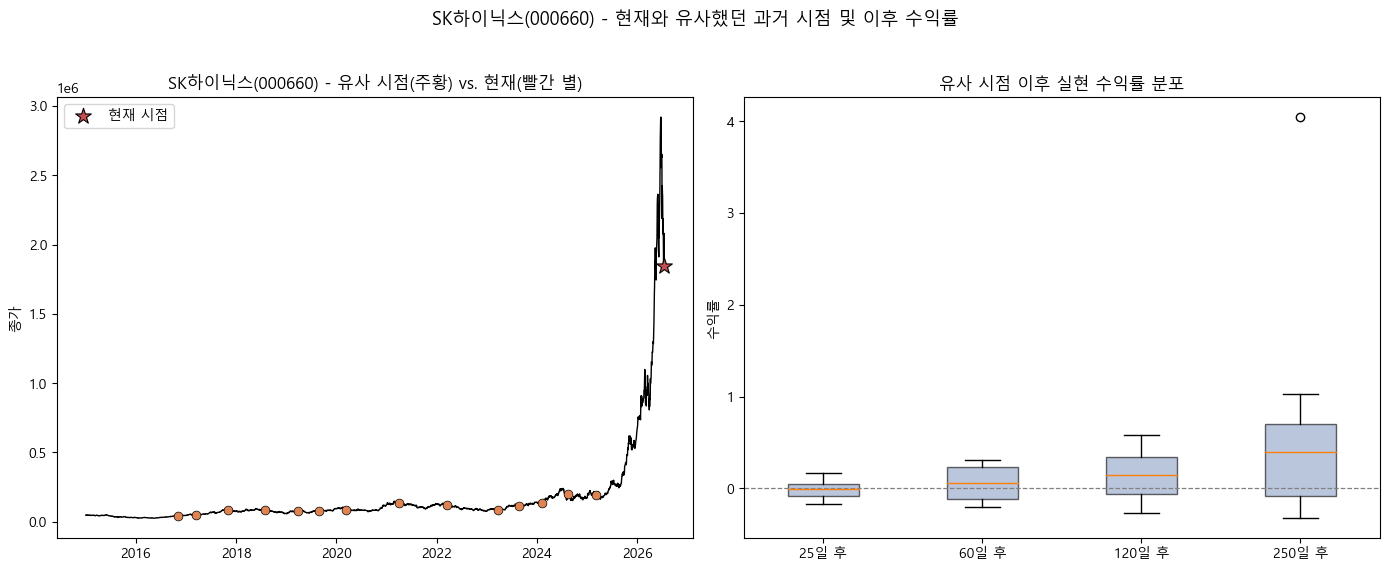

In [70]:
# Cell 23: [시각화 7] 유사 시점 위치 표시 + 이후 수익률 분포

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (좌) 주가 차트 위에 유사 시점들을 표시
ax = axes[0]
ax.plot(analysis_df.index, analysis_df["Close"], color="black", linewidth=1)
for d in selected_dates:
    ax.scatter(d, analysis_df.loc[d, "Close"], color="#DD8452", s=40, zorder=5,
               edgecolor="black", linewidth=0.5)
ax.scatter(current_date, analysis_df.loc[current_date, "Close"], color="#C44E52", s=140,
           marker="*", zorder=6, edgecolor="black", linewidth=0.8, label="현재 시점")
ax.set_title(f"{TICKER_NAME}({TICKER}) - 유사 시점(주황) vs. 현재(빨간 별)")
ax.set_ylabel("종가")
ax.legend(loc="upper left")

# (우) 유사 시점 이후 수익률 분포 (박스플롯, 수평선=0)
ax2 = axes[1]
box_data = [analog_results[f"fwd_{h}d_ret"].dropna().values for h in ANALOG_FORWARD_HORIZONS]
bp = ax2.boxplot(box_data, labels=[f"{h}일 후" for h in ANALOG_FORWARD_HORIZONS], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#8CA0C6")
    patch.set_alpha(0.6)
ax2.axhline(0, color="gray", linewidth=0.9, linestyle="--")
ax2.set_title("유사 시점 이후 실현 수익률 분포")
ax2.set_ylabel("수익률")

fig.suptitle(f"{TICKER_NAME}({TICKER}) - 현재와 유사했던 과거 시점 및 이후 수익률", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()


In [74]:
analysis_df[["Close"]].to_csv(r"C:\Users\82108\OneDrive\유튜브\barrons_WSJ_pw\sk_hynix_000660_price.csv")

In [72]:
print("TICKER:", TICKER, "| TICKER_NAME:", TICKER_NAME)
print(price_df.tail())
for d in ["2020-01-02", "2023-01-02", "2024-08-16", price_df.index[-1].strftime("%Y-%m-%d")]:
    try:
        print(d, price_df.loc[d, "Close"] if d in price_df.index.strftime("%Y-%m-%d") else "휴장/데이터없음")
    except Exception as e:
        print(d, "조회 실패:", e)

TICKER: 000660 | TICKER_NAME: SK하이닉스
              Close
Date               
2026-07-10  2180000
2026-07-13  1845000
2026-07-14  1913000
2026-07-15  2082000
2026-07-16  1842000
2020-01-02 94700
2023-01-02 75700
2024-08-16 199700
2026-07-16 1842000
